In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/wafer_process_data.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nData types:")
print(df.dtypes)

  wafer_id lot_id tool_id  temperature_C  pressure_mTorr  deposition_time_s  \
0    W0001   L001       A     401.025268       51.167856          61.952612   
1    W0002   L001       C     405.628513       49.281416          62.342267   
2    W0003   L001       B     402.851272       51.181310          60.048006   
3    W0004   L001       B     398.269289       52.217407          58.869873   
4    W0005   L001       A     397.304756       51.640964          60.689958   

   film_thickness_nm  defect_count  yield_pct  
0         100.189450             2  98.057511  
1         100.644608             5  94.933443  
2         100.524534             3  97.148261  
3         100.139560             4  97.005463  
4         100.025661             2  97.118911  

Shape: (500, 9)

Data types:
wafer_id                 str
lot_id                   str
tool_id                  str
temperature_C        float64
pressure_mTorr       float64
deposition_time_s    float64
film_thickness_nm    float64
defe

In [2]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
wafer_id             0
lot_id               0
tool_id              0
temperature_C        0
pressure_mTorr       0
deposition_time_s    0
film_thickness_nm    0
defect_count         0
yield_pct            0
dtype: int64


In [3]:
print("\nDuplicate wafers:")
print(df["wafer_id"].duplicated().sum())


Duplicate wafers:
0


In [4]:
print("\nProcess summary:")
print(
    df[
        [
            "temperature_C",
            "pressure_mTorr",
            "deposition_time_s",
            "film_thickness_nm",
            "defect_count",
            "yield_pct"
        ]
    ].describe()
)


Process summary:
       temperature_C  pressure_mTorr  deposition_time_s  film_thickness_nm  \
count     500.000000      500.000000         500.000000         500.000000   
mean      400.022860       50.145426          60.108628         100.094027   
std         3.021186        1.990865           1.483304           0.412082   
min       391.909340       44.207489          55.617974          98.708837   
25%       398.047177       48.795141          59.084581          99.833001   
50%       399.901828       50.160465          60.089020         100.087332   
75%       401.983979       51.416341          61.142343         100.339409   
max       409.236642       55.159419          64.789661         101.241159   

       defect_count   yield_pct  
count    500.000000  500.000000  
mean       4.062000   96.263716  
std        2.707178    1.374633  
min        0.000000   88.615351  
25%        2.000000   95.625714  
50%        4.000000   96.469607  
75%        5.000000   97.153669  
max    

In [5]:
tool_summary = df.groupby("tool_id").agg(
    wafer_count=("wafer_id", "count"),
    mean_thickness=("film_thickness_nm", "mean"),
    thickness_std=("film_thickness_nm", "std"),
    mean_defects=("defect_count", "mean"),
    mean_yield=("yield_pct", "mean")
)

print("\nTool summary:")
print(tool_summary)


Tool summary:
         wafer_count  mean_thickness  thickness_std  mean_defects  mean_yield
tool_id                                                                      
A                207       99.979998       0.364644      4.014493   96.331382
B                162      100.389417       0.358131      4.160494   96.078181
C                131       99.908918       0.343958      4.015267   96.386234


In [6]:
lot_summary = df.groupby("lot_id").agg(
    wafer_count=("wafer_id", "count"),
    mean_thickness=("film_thickness_nm", "mean"),
    mean_defects=("defect_count", "mean"),
    mean_yield=("yield_pct", "mean")
)

print("\nLot summary:")
print(lot_summary)


Lot summary:
        wafer_count  mean_thickness  mean_defects  mean_yield
lot_id                                                       
L001             25      100.174653          3.24   96.527545
L002             25      100.173332          3.60   96.535027
L003             25      100.024715          3.84   96.443290
L004             25      100.109591          4.12   96.145758
L005             25      100.073770          3.64   96.520033
L006             25      100.005522          3.32   96.590228
L007             25      100.070427          3.64   96.454448
L008             25       99.990733          3.52   96.587379
L009             25      100.119257          3.88   96.318859
L010             25      100.147256          3.08   96.677090
L011             25      100.104692          3.56   96.492726
L012             25      100.097636         11.92   92.781399
L013             25      100.133241          3.84   96.364561
L014             25      100.158308          4.12   96.2

In [7]:
lowest_yield_lots = lot_summary.sort_values(
    "mean_yield"
)

print("\nLowest-yield lots:")
print(lowest_yield_lots.head())


Lowest-yield lots:
        wafer_count  mean_thickness  mean_defects  mean_yield
lot_id                                                       
L012             25      100.097636         11.92   92.781399
L004             25      100.109591          4.12   96.145758
L014             25      100.158308          4.12   96.264117
L015             25      100.092856          3.60   96.272654
L009             25      100.119257          3.88   96.318859


In [8]:
highest_defect_lots = lot_summary.sort_values(
    "mean_defects",
    ascending=False
)

print("\nHighest-defect lots:")
print(highest_defect_lots.head())


Highest-defect lots:
        wafer_count  mean_thickness  mean_defects  mean_yield
lot_id                                                       
L012             25      100.097636         11.92   92.781399
L014             25      100.158308          4.12   96.264117
L004             25      100.109591          4.12   96.145758
L017             25      100.069357          3.96   96.412991
L009             25      100.119257          3.88   96.318859


In [10]:
overall_yield = df["yield_pct"].mean()
overall_defects = df["defect_count"].mean()

print("\nOverall mean yield:", overall_yield)
print("Overall mean defects:", overall_defects)


Overall mean yield: 96.26371594180779
Overall mean defects: 4.062


In [11]:
worst_lot = lowest_yield_lots.iloc[0]

print("\nWorst lot:")
print(worst_lot)


Worst lot:
wafer_count        25.000000
mean_thickness    100.097636
mean_defects       11.920000
mean_yield         92.781399
Name: L012, dtype: float64


In [12]:
worst_lot_id = lowest_yield_lots.index[0]

print("Worst lot ID:", worst_lot_id)

Worst lot ID: L012


In [13]:
problem_lot = df[df["lot_id"] == "L012"]
normal_lots = df[df["lot_id"] != "L012"]

In [14]:
columns = [
    "temperature_C",
    "pressure_mTorr",
    "deposition_time_s",
    "film_thickness_nm",
    "defect_count",
    "yield_pct"
]

comparison = pd.DataFrame({
    "L012": problem_lot[columns].mean(),
    "Other lots": normal_lots[columns].mean()
})

comparison["difference"] = (
    comparison["L012"] - comparison["Other lots"]
)

print("\nL012 vs other lots:")
print(comparison)


L012 vs other lots:
                         L012  Other lots  difference
temperature_C      399.535673  400.048501   -0.512828
pressure_mTorr      50.251929   50.139821    0.112109
deposition_time_s   60.047807   60.111829   -0.064022
film_thickness_nm  100.097636  100.093837    0.003799
defect_count        11.920000    3.648421    8.271579
yield_pct           92.781399   96.446996   -3.665597


In [15]:
print("\nTools used for L012:")
print(
    problem_lot["tool_id"].value_counts()
)


Tools used for L012:
tool_id
A    11
B     9
C     5
Name: count, dtype: int64


In [16]:
print("\nL012 tool distribution:")
print(
    problem_lot["tool_id"].value_counts(normalize=True) * 100
)


L012 tool distribution:
tool_id
A    44.0
B    36.0
C    20.0
Name: proportion, dtype: float64


In [17]:
print("\nOverall tool distribution:")
print(
    df["tool_id"].value_counts(normalize=True) * 100
)


Overall tool distribution:
tool_id
A    41.4
B    32.4
C    26.2
Name: proportion, dtype: float64


In [18]:
defect_yield_corr = df["defect_count"].corr(
    df["yield_pct"]
)

print(
    "\nDefect-yield correlation:",
    defect_yield_corr
)


Defect-yield correlation: -0.9023578246052865


In [21]:
from scipy.stats import ttest_ind

In [19]:
process_variables = [
    "temperature_C",
    "pressure_mTorr",
    "deposition_time_s",
    "film_thickness_nm"
]

In [22]:
for variable in process_variables:

    l012_values = problem_lot[variable]
    other_values = normal_lots[variable]

    t_stat, p_value = ttest_ind(
        l012_values,
        other_values,
        equal_var=False
    )

    print(
        variable,
        "t-statistic:",
        t_stat,
        "p-value:",
        p_value
    )

temperature_C t-statistic: -0.738725889532289 p-value: 0.46668910009302556
pressure_mTorr t-statistic: 0.23354188193801667 p-value: 0.8171837767886236
deposition_time_s t-statistic: -0.2188601722953143 p-value: 0.8284147305334257
film_thickness_nm t-statistic: 0.03893683292358426 p-value: 0.9692396140577786


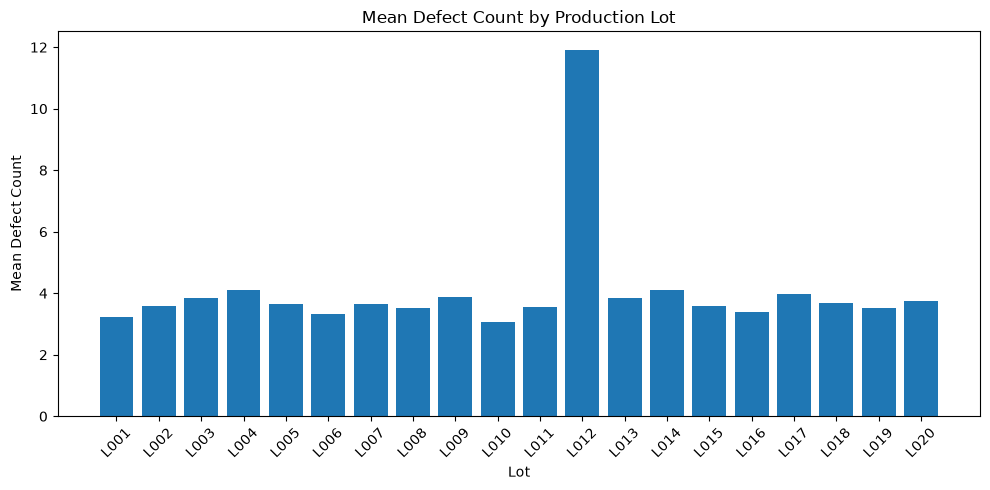

In [23]:
lot_summary_plot = lot_summary.reset_index()

plt.figure(figsize=(10, 5))

plt.bar(
    lot_summary_plot["lot_id"],
    lot_summary_plot["mean_defects"]
)

plt.xlabel("Lot")
plt.ylabel("Mean Defect Count")
plt.title("Mean Defect Count by Production Lot")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "figures/defects_by_lot.png",
    dpi=300
)

plt.show()

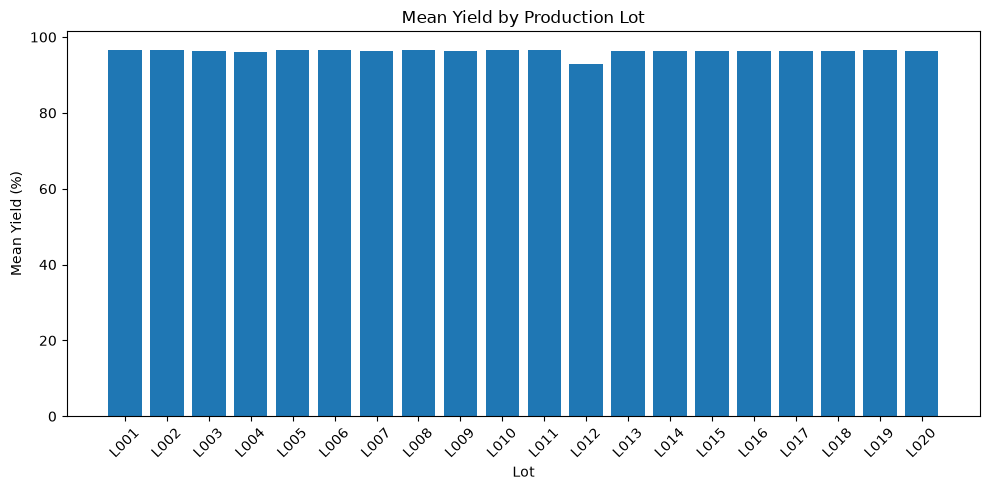

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(
    lot_summary_plot["lot_id"],
    lot_summary_plot["mean_yield"]
)

plt.xlabel("Lot")
plt.ylabel("Mean Yield (%)")
plt.title("Mean Yield by Production Lot")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "figures/yield_by_lot.png",
    dpi=300
)

plt.show()

In [25]:
numeric_columns = [
    "temperature_C",
    "pressure_mTorr",
    "deposition_time_s",
    "film_thickness_nm",
    "defect_count",
    "yield_pct"
]

correlation_matrix = df[numeric_columns].corr()

print("\nCorrelation matrix:")
print(correlation_matrix.round(3))


Correlation matrix:
                   temperature_C  pressure_mTorr  deposition_time_s  \
temperature_C              1.000           0.035             -0.060   
pressure_mTorr             0.035           1.000             -0.015   
deposition_time_s         -0.060          -0.015              1.000   
film_thickness_nm          0.615           0.151              0.360   
defect_count               0.024           0.020             -0.011   
yield_pct                 -0.057          -0.008             -0.046   

                   film_thickness_nm  defect_count  yield_pct  
temperature_C                  0.615         0.024     -0.057  
pressure_mTorr                 0.151         0.020     -0.008  
deposition_time_s              0.360        -0.011     -0.046  
film_thickness_nm              1.000         0.065     -0.144  
defect_count                   0.065         1.000     -0.902  
yield_pct                     -0.144        -0.902      1.000  


In [26]:
thickness_correlations = (
    correlation_matrix["film_thickness_nm"]
    .drop("film_thickness_nm")
    .sort_values(key=abs, ascending=False)
)

print("\nCorrelations with film thickness:")
print(thickness_correlations)


Correlations with film thickness:
temperature_C        0.615187
deposition_time_s    0.359878
pressure_mTorr       0.151229
yield_pct           -0.144240
defect_count         0.065397
Name: film_thickness_nm, dtype: float64


In [27]:
yield_correlations = (
    correlation_matrix["yield_pct"]
    .drop("yield_pct")
    .sort_values(key=abs, ascending=False)
)

print("\nCorrelations with yield:")
print(yield_correlations)


Correlations with yield:
defect_count        -0.902358
film_thickness_nm   -0.144240
temperature_C       -0.056973
deposition_time_s   -0.045730
pressure_mTorr      -0.008206
Name: yield_pct, dtype: float64


In [ ]:
thickness = (
    thickness
    + 0.08 * (df["temperature_C"] - 400)
)

In [28]:
df["temperature_deviation"] = abs(
    df["temperature_C"] - 400
)

df["pressure_deviation"] = abs(
    df["pressure_mTorr"] - 50
)

df["thickness_deviation"] = abs(
    df["film_thickness_nm"] - 100
)

In [29]:
print(
    "Temperature deviation vs defects:",
    df["temperature_deviation"].corr(df["defect_count"])
)

print(
    "Pressure deviation vs defects:",
    df["pressure_deviation"].corr(df["defect_count"])
)

print(
    "Thickness deviation vs yield:",
    df["thickness_deviation"].corr(df["yield_pct"])
)

Temperature deviation vs defects: 0.20212899466431292
Pressure deviation vs defects: 0.12718196621146408
Thickness deviation vs yield: -0.3436427690277588


In [31]:
print("\n--- PROCESS INVESTIGATION SUMMARY ---")

print(f"Worst-performing lot: {worst_lot_id}")

print(
    f"L012 mean defects: "
    f"{problem_lot['defect_count'].mean():.2f}"
)

print(
    f"Other lots mean defects: "
    f"{normal_lots['defect_count'].mean():.2f}"
)

print(
    f"L012 mean yield: "
    f"{problem_lot['yield_pct'].mean():.2f}%"
)

print(
    f"Other lots mean yield: "
    f"{normal_lots['yield_pct'].mean():.2f}%"
)

print(
    f"Defect-yield correlation: "
    f"{defect_yield_corr:.3f}"
)

print(
    "Conclusion: L012 shows a major defect excursion and yield loss. "
    "No significant mean shift was detected in the recorded process "
    "parameters, suggesting investigation of an unmeasured special cause."
)


--- PROCESS INVESTIGATION SUMMARY ---
Worst-performing lot: L012
L012 mean defects: 11.92
Other lots mean defects: 3.65
L012 mean yield: 92.78%
Other lots mean yield: 96.45%
Defect-yield correlation: -0.902
Conclusion: L012 shows a major defect excursion and yield loss. No significant mean shift was detected in the recorded process parameters, suggesting investigation of an unmeasured special cause.
